# Nested Langevin active inverse optimization — tiny sanity examples

This notebook implements the agreed v2 algorithm and stores **all results inline**. You do not need to run it to see the tables and plots.

Two deliberately small, clean MIN-expert examples use dimension 2, six observations, 12 candidate queries, four retained parameter samples, and 64 hidden test queries:

1. **Trivial independent binary:** choose each of two entries independently. Only the signs of theta are identifiable from decisions; zero regret does NOT imply zero angular error.
2. **Small coupled choice:** choose exactly one of two entries. The relative parameter values affect decisions, and different queries can have different disagreement scores.

The true parameter is (-1, 1) normalized to unit length, and the objective is F(theta, s, x) = theta dot (s * x). Both parameter noise and observation noise are disabled in these sanity examples. The algorithm sees only public (S, Y) and the forward MIN solver.

At each round the algorithm samples parameters with Gaussian-smoothed **nested** Langevin dynamics, reports the **first retained latent parameter**, and chooses the candidate S with the largest predicted-decision disagreement across **all four samples**. Inner z states are projected into [-1, 1]^2; outer u states are never projected.

**For these trajectory demonstrations only**, external zero-regret stopping is disabled, so every time step remains visible. The benchmark's stopping rule is still available and unchanged. We report the first zero-regret step, but a zero on this finite test set is not a generalization proof.

Finite-step sampling is approximate. These are sanity checks, not evidence of convergence, noise robustness, or superiority over random querying. A sampled estimate can improve and then worsen.


In [1]:
from pathlib import Path
from dataclasses import asdict
import sys
import time

root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "invoptlab").exists())
sys.path.insert(0, str(root / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from invoptlab.active import (
    ActiveBenchmarkRunner, ActiveEvaluationConfig, ActiveScenarioConfig,
    DecisionSpaceConfig, ExpertConfig, ObservationNoiseConfig, ParameterNoiseConfig,
    QuerySpaceConfig, RegretStoppingConfig, NestedLangevinConfig,
    NestedLangevinActiveAlgorithm, angular_error_degrees, evaluate_active_run,
    make_decision_space, normalized_test_regret, sample_uniform_test_queries,
)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("Local package:", root / "src" / "invoptlab")


Local package: C:\Users\payam\Desktop\Inverse Optimization\src\invoptlab


## Inputs — change these to run your own small example

Tau values are **variances**. Every outer step runs a complete inner chain with a fixed u. Each trajectory includes a fresh final conditional run, and retains a late z state, not the inner mean or outer u. No parameter normalization is applied to the reported sample. All settings below are public and do not depend on hidden test outcomes.


In [2]:
sampler_config = NestedLangevinConfig(
    sampler="projected_langevin", point_estimate="first", query_tie_breaking="first",  # Historical v2 run
    beta=20.0,
    parameter_domain="box", bound=1.0,
    tau_schedule=(0.5, 0.1, 0.02),
    inner_step_sizes=(0.02, 0.005, 0.001),
    outer_step_sizes=(0.1, 0.02, 0.004),
    inner_steps=64, inner_burn_in=32, inner_thinning=4,
    outer_steps=8, theta_samples=4,
    initialization_std=1.0,
    warm_start=True, warm_start_renoise_std=0.0, warm_start_inner=False,
    workers=1, record_chain_trace=True,
)
scenarios = {
    "Independent binary (trivial)": ActiveScenarioConfig(
        name="nested-langevin-trivial-2d", dimension=2, horizon=6, seed=0,
        true_theta=[-1.0, 1.0],
        decision_space=DecisionSpaceConfig(kind="independent_binary"),
        query_space=QuerySpaceConfig(kind="balanced", candidate_count=12),
        expert=ExpertConfig(kind="min"),
        parameter_noise=ParameterNoiseConfig(kind="none"),
        observation_noise=ObservationNoiseConfig(kind="clean"),
    ),
    "Choose one of two (coupled)": ActiveScenarioConfig(
        name="nested-langevin-coupled-2d", dimension=2, horizon=6, seed=0,
        true_theta=[-1.0, 1.0],
        decision_space=DecisionSpaceConfig(kind="fixed_cardinality", cardinality=1),
        query_space=QuerySpaceConfig(kind="balanced", candidate_count=12),
        expert=ExpertConfig(kind="min"),
        parameter_noise=ParameterNoiseConfig(kind="none"),
        observation_noise=ObservationNoiseConfig(kind="clean"),
    ),
}
evaluation_config = ActiveEvaluationConfig(
    test_query_count=64, seed=9103, evaluate_trajectory=True,
    query_distribution="uniform_unit_sphere",
)
display(pd.DataFrame({"input": list(asdict(sampler_config)), "value": [str(v) for v in asdict(sampler_config).values()]}))


,input,value
0,beta,20.0
1,parameter_domain,box
2,bound,1.0
3,tau_schedule,"(0.5, 0.1, 0.02)"
4,inner_step_sizes,"(0.02, 0.005, 0.001)"
5,outer_step_sizes,"(0.1, 0.02, 0.004)"
6,inner_steps,64
7,inner_burn_in,32
8,inner_thinning,4
9,outer_steps,8


In [3]:
runs, evaluations, snapshots, algorithms = {}, {}, {}, {}
wall_times = {}
for name, scenario in scenarios.items():
    algorithm = NestedLangevinActiveAlgorithm(sampler_config)
    started = time.perf_counter()
    run = ActiveBenchmarkRunner(stopping_config=RegretStoppingConfig(enabled=False)).run(scenario, algorithm)
    wall_times[name] = time.perf_counter() - started
    evaluations[name] = evaluate_active_run(run, evaluation_config)
    runs[name], algorithms[name] = run, algorithm
    snapshots[name] = [run.records[0].action_diagnostics] + [r.update_diagnostics for r in run.records]
    print(f"{name}: completed {len(run.records)} steps in {wall_times[name]:.2f} seconds.")


Independent binary (trivial): completed 6 steps in 7.53 seconds.


Choose one of two (coupled): completed 6 steps in 6.20 seconds.


## Results at every time step

Time 0 is the initial sample before any demonstrations. Every subsequent row is the estimate **after** observing Y at that step. Regret is the existing benchmark's normalized clean MIN regret on the same 64 independent hidden uniform queries at every step. The algorithm never receives those test queries, their answers, or the true parameter.


In [4]:
rows = []
for name, run in runs.items():
    evaluation = evaluations[name]
    initial = run.records[0].theta_hat_before
    space = make_decision_space(run.scenario.decision_space, 2, np.random.default_rng(0))
    hidden = sample_uniform_test_queries(2, 64, scenario_seed=run.scenario.seed, evaluation_seed=9103)
    initial_regret, initial_zero, _ = normalized_test_regret(initial, run.true_theta, hidden, space)
    angles = [angular_error_degrees(initial, run.true_theta)[0]] + evaluation.angular_error_history_degrees
    regrets = [initial_regret] + evaluation.normalized_regret_history
    zero_rates = [initial_zero] + evaluation.zero_regret_rate_history
    for t, snap in enumerate(snapshots[name]):
        theta = np.asarray(snap["theta_hat"])
        rows.append({
            "example": name, "t": t, "theta_1": theta[0], "theta_2": theta[1],
            "theta_norm": np.linalg.norm(theta), "angular_error_deg": angles[t],
            "test_regret": regrets[t], "zero_regret_fraction": zero_rates[t],
            "forward_calls_total": snap["forward_calls_total"],
        })
trajectory_table = pd.DataFrame(rows)
display(trajectory_table.round(5))
summary_rows = []
for name, evaluation in evaluations.items():
    summary_rows.append({
        "example": name, "steps": len(runs[name].records),
        "final_regret": evaluation.final_normalized_regret,
        "final_zero_regret_fraction": evaluation.final_zero_regret_rate,
        "final_angle_deg": evaluation.final_angular_error_degrees,
        "first_zero_regret_step": evaluation.first_zero_regret_step,
        "stable_zero_regret_step": evaluation.stable_zero_regret_step,
        "wall_seconds": wall_times[name],
    })
display(pd.DataFrame(summary_rows).round(5))


,example,t,theta_1,theta_2,theta_norm,angular_error_deg,test_regret,zero_regret_fraction,forward_calls_total
0,Independent binary (trivial),0,0.97416,-0.22325,0.99942,147.90794,1.00000,0.00000,48
1,Independent binary (trivial),1,-0.08174,0.40507,0.41323,33.59165,0.00000,1.00000,6448
2,Independent binary (trivial),2,-0.10273,0.62323,0.63164,35.64016,0.00000,1.00000,19296
3,Independent binary (trivial),3,-0.73992,0.85618,1.13160,4.16615,0.00000,1.00000,38544
4,Independent binary (trivial),4,-0.11286,0.44046,0.45469,30.62781,0.00000,1.00000,64192
5,Independent binary (trivial),5,-0.92496,0.08007,0.92842,40.05217,0.00000,1.00000,96240
6,Independent binary (trivial),6,-0.47021,0.23536,0.52582,18.41043,0.00000,1.00000,134688
7,Choose one of two (coupled),0,0.97416,-0.22325,0.99942,147.90794,0.81250,0.18750,48
8,Choose one of two (coupled),1,0.26755,-0.61615,0.67173,158.47166,0.84375,0.15625,6448
9,Choose one of two (coupled),2,-0.23183,0.06419,0.24055,29.52272,0.17188,0.82812,19296


,example,steps,final_regret,final_zero_regret_fraction,final_angle_deg,first_zero_regret_step,stable_zero_regret_step,wall_seconds
0,Independent binary (trivial),6,0.0,1.0,18.41043,1,1,7.53394
1,Choose one of two (coupled),6,0.0,1.0,5.68127,3,6,6.19791


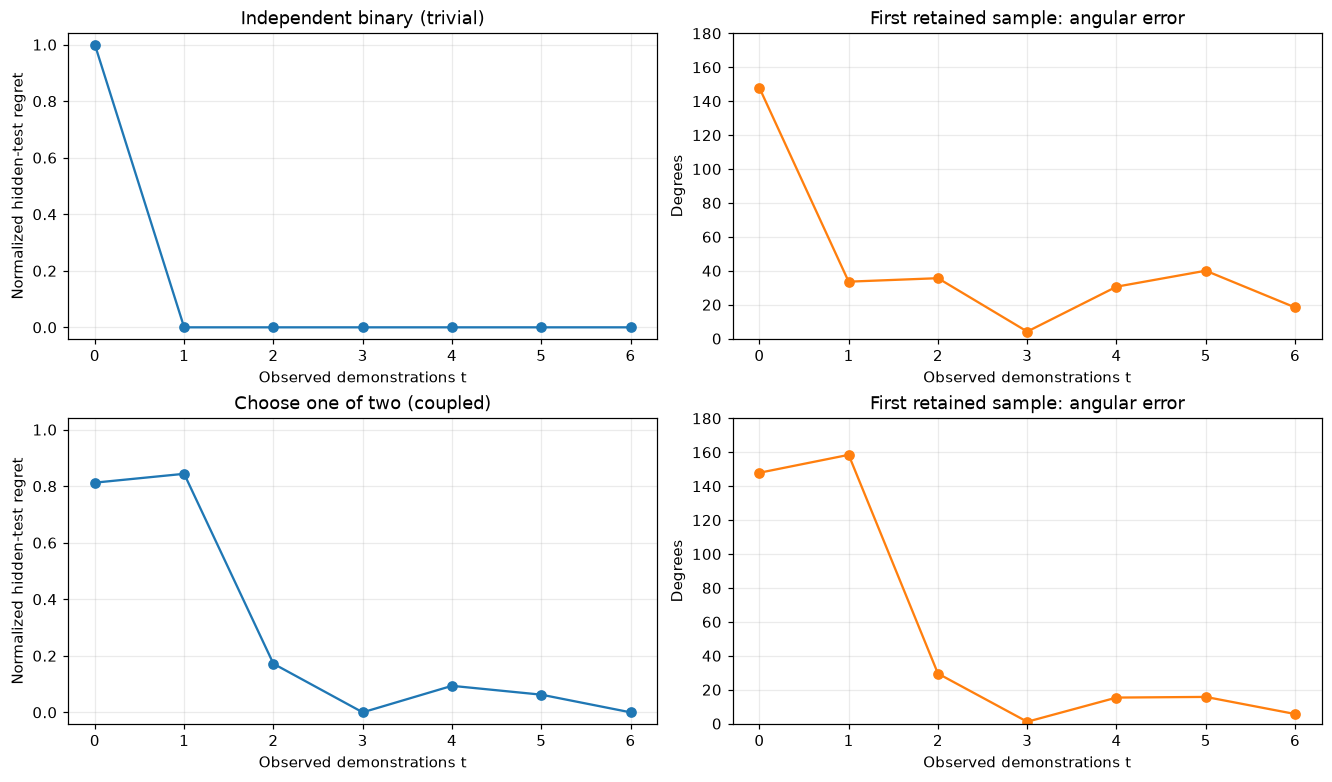

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for row, name in enumerate(runs):
    data = trajectory_table[trajectory_table.example == name]
    axes[row, 0].plot(data.t, data.test_regret, "o-", color="tab:blue")
    axes[row, 0].set(title=name, xlabel="Observed demonstrations t", ylabel="Normalized hidden-test regret", ylim=(-0.04, 1.04))
    axes[row, 1].plot(data.t, data.angular_error_deg, "o-", color="tab:orange")
    axes[row, 1].set(title="First retained sample: angular error", xlabel="Observed demonstrations t", ylabel="Degrees", ylim=(0, 180))
    for ax in axes[row]:
        ax.set_xticks(range(7))
        ax.grid(alpha=0.25)
plt.show()


## Loss as a function of theta, and all retained samples — at every step

The background is the cumulative hard-MIN loss L_t(theta), evaluated over the full 2D box. Each panel shows all four samples, the first sample used as the estimate, and the hidden truth (plotted for the researcher only). The same color scale is used throughout each example. At t=0 the loss is identically zero. No hard cone is fitted by this algorithm.


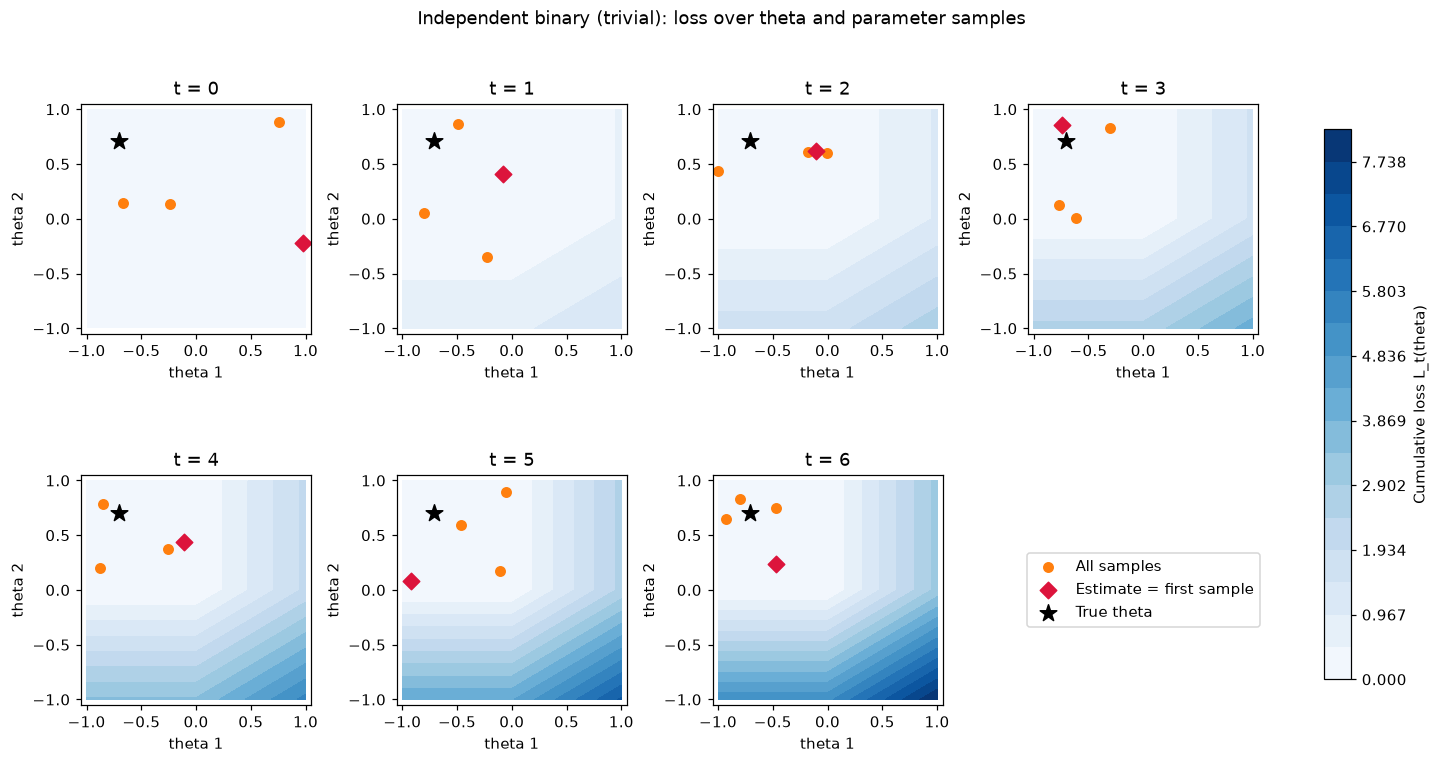

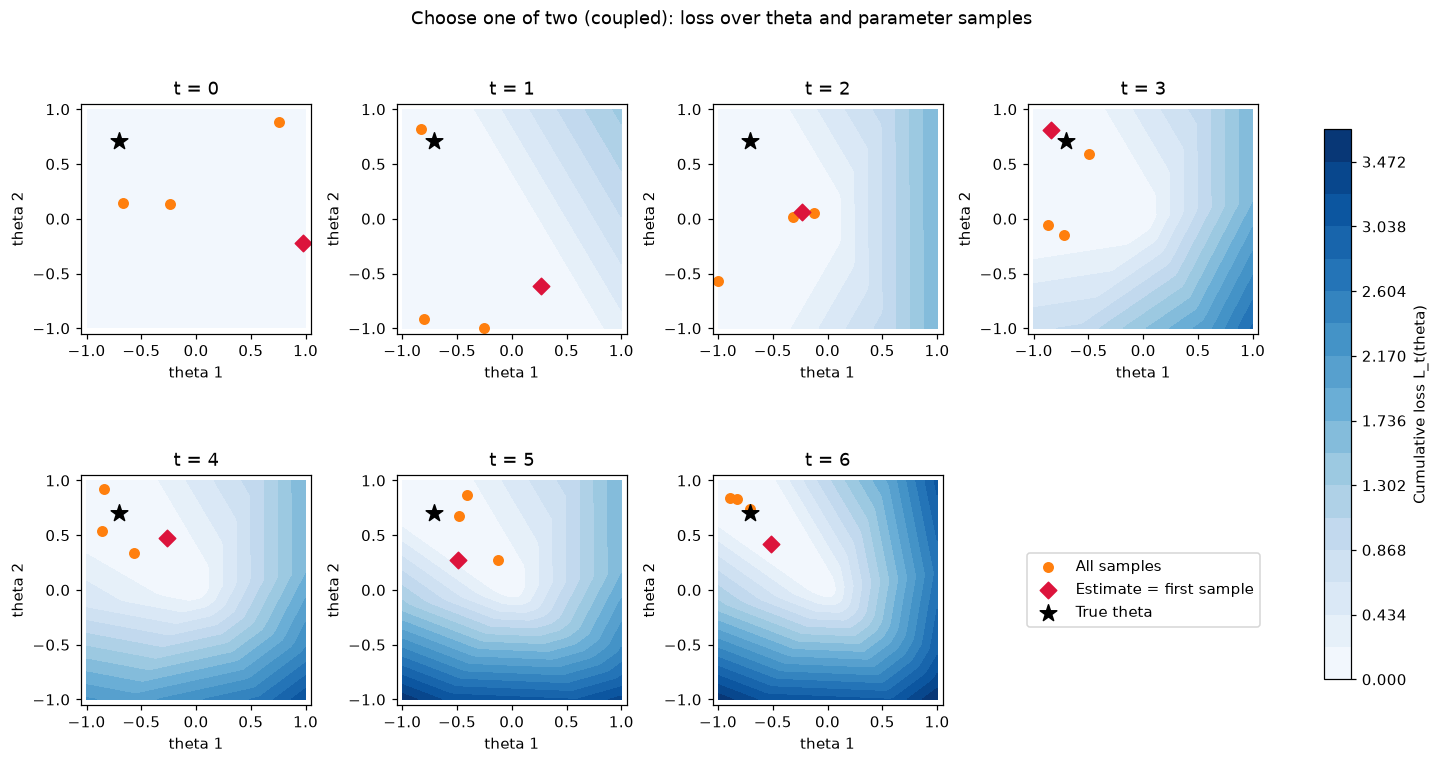

In [6]:
coordinates = np.linspace(-1, 1, 61)
xx, yy = np.meshgrid(coordinates, coordinates)
points = np.column_stack([xx.ravel(), yy.ravel()])
for name, run in runs.items():
    space = make_decision_space(run.scenario.decision_space, 2, np.random.default_rng(0))
    decisions = np.asarray(space.enumerate_decisions())
    loss = np.zeros(len(points))
    landscapes = [loss.copy()]
    for record in run.records:
        costs = points * record.query
        loss += costs @ record.observed_decision - (costs @ decisions.T).min(axis=1)
        landscapes.append(loss.copy())
    levels = np.linspace(0, max(1e-8, landscapes[-1].max()), 18)
    fig, axes = plt.subplots(2, 4, figsize=(13, 7), constrained_layout=True)
    fig.suptitle(f"{name}: loss over theta and parameter samples")
    for t, ax in enumerate(axes.flat):
        if t > len(run.records):
            ax.axis("off")
            continue
        contour = ax.contourf(xx, yy, landscapes[t].reshape(xx.shape), levels=levels, cmap="Blues")
        samples = np.asarray(snapshots[name][t]["theta_samples"])
        ax.scatter(samples[:, 0], samples[:, 1], c="tab:orange", s=38, label="All samples")
        ax.scatter(*samples[0], c="crimson", marker="D", s=58, label="Estimate = first sample")
        ax.scatter(*run.true_theta, c="black", marker="*", s=130, label="True theta")
        ax.set(title=f"t = {t}", xlabel="theta 1", ylabel="theta 2", xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect="equal")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    axes.flat[-1].legend(handles, labels, loc="center", fontsize=10)
    fig.colorbar(contour, ax=list(axes.flat[:-1]), label="Cumulative loss L_t(theta)", shrink=0.75)
    plt.show()


## How the next S is chosen — every query round

Bars show the disagreement for all 12 candidates; red marks the selected query. These scores use the samples **before** the corresponding observation. Exact ties choose the first candidate deterministically.

In the trivial independent-binary problem with nonzero query coordinates, the disagreement can be identical for every S: changing a query coordinate's sign flips every prediction together. Thus that example checks estimation and execution, but does not establish an advantage for active selection. The coupled example makes the selection behavior more informative.


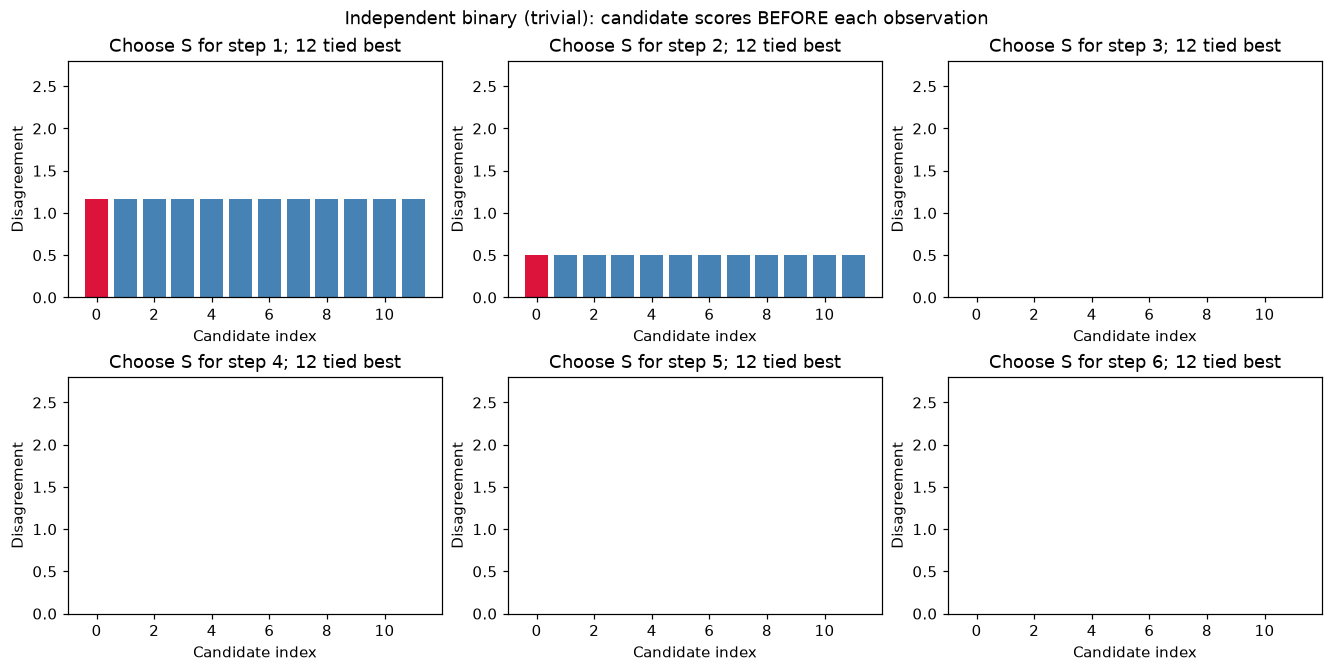

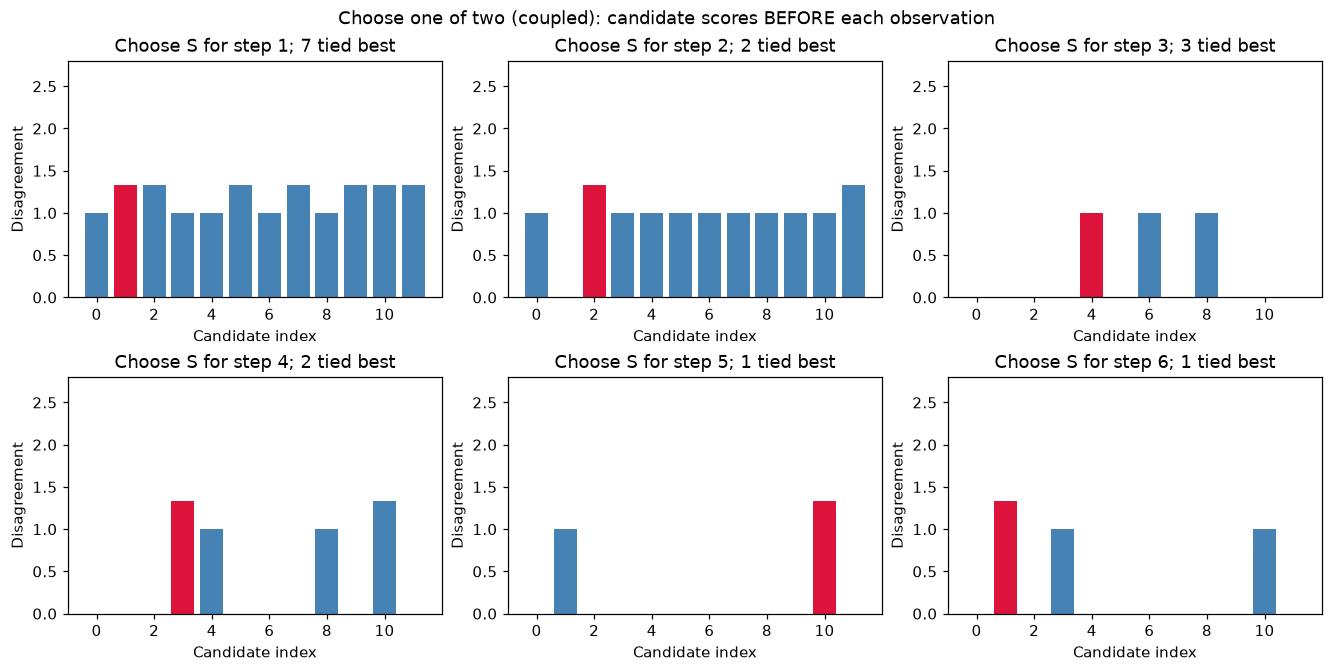

,example,step,selected_index,S,observed_Y,selected_score,number_tied_best
0,Independent binary (trivial),1,0,"[-0.5101, -0.8601]","[0, 1]",1.166667,12
1,Independent binary (trivial),2,0,"[-0.5101, -0.8601]","[0, 1]",0.500000,12
2,Independent binary (trivial),3,0,"[-0.5101, -0.8601]","[0, 1]",0.000000,12
3,Independent binary (trivial),4,0,"[-0.5101, -0.8601]","[0, 1]",0.000000,12
4,Independent binary (trivial),5,0,"[-0.5101, -0.8601]","[0, 1]",0.000000,12
5,Independent binary (trivial),6,0,"[-0.5101, -0.8601]","[0, 1]",0.000000,12
6,Choose one of two (coupled),1,1,"[0.8601, -0.5101]","[1, 0]",1.333333,7
7,Choose one of two (coupled),2,2,"[-0.8653, -0.5013]","[0, 1]",1.333333,2
8,Choose one of two (coupled),3,4,"[-0.1521, -0.9884]","[0, 1]",1.000000,3
9,Choose one of two (coupled),4,3,"[0.5013, -0.8653]","[0, 1]",1.333333,2


In [7]:
for name, run in runs.items():
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
    fig.suptitle(f"{name}: candidate scores BEFORE each observation")
    for ax, record in zip(axes.flat, run.records):
        diagnostics = record.action_diagnostics
        indices = np.asarray(diagnostics["candidate_indices"])
        scores = np.asarray(diagnostics["candidate_scores"])
        colors = ["crimson" if i == diagnostics["candidate_index"] else "steelblue" for i in indices]
        ax.bar(indices, scores, color=colors)
        ax.set(title=f"Choose S for step {record.step}; {diagnostics['candidate_score_ties']} tied best",
               xlabel="Candidate index", ylabel="Disagreement", ylim=(0, 2.8))
    plt.show()
selection_rows = [{
    "example": name, "step": r.step, "selected_index": r.action_diagnostics["candidate_index"],
    "S": np.round(r.query, 4).tolist(), "observed_Y": r.observed_decision.tolist(),
    "selected_score": r.action_diagnostics["selected_score"],
    "number_tied_best": r.action_diagnostics["candidate_score_ties"],
} for name, run in runs.items() for r in run.records]
display(pd.DataFrame(selection_rows))


## Numerical diagnostics and executable sanity assertions

The plots below summarize the largest score/state norms across the four trajectories at each round, plus the rate of inner proposals that needed projection. High projection rates or exploding norms are warnings about numerical settings, not evidence of better learning. Full inner/outer traces are available in each snapshot, with round, trajectory, tau, step numbers, norms, and forward-solver counters.

There are 64 inner steps per conditional run, eight outer steps at each of three smoothing levels, and one extra final conditional run per trajectory. No larger training or benchmark grid is run here.


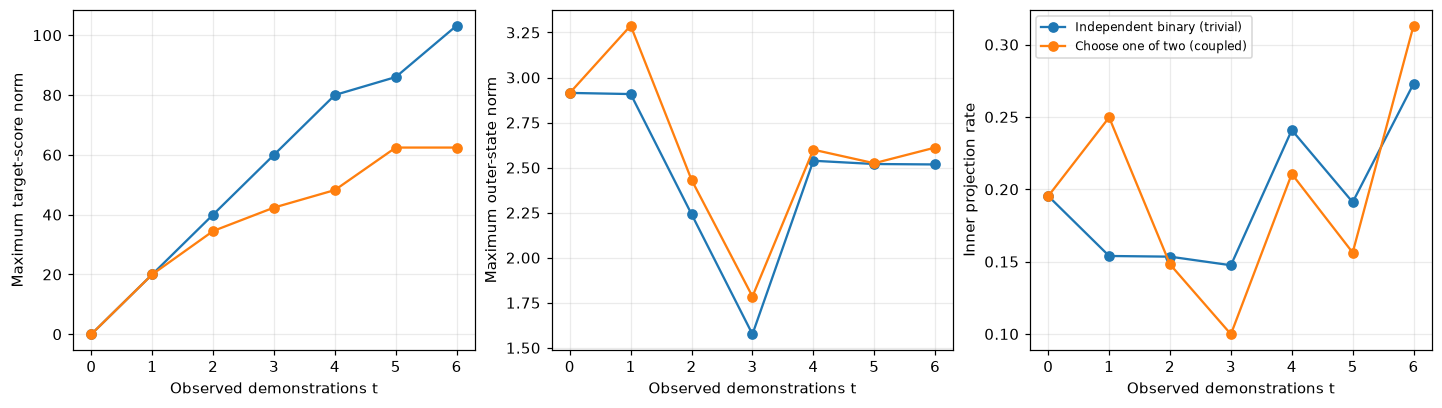

Independent binary (trivial) — all structural checks passed.
Choose one of two (coupled) — all structural checks passed.
These checks verify the implemented contract; they do not certify exact sampling or convergence.


In [8]:
diagnostic_rows = []
for name, history in snapshots.items():
    for t, snapshot in enumerate(history):
        trajectories = snapshot["trajectories"]
        diagnostic_rows.append({
            "example": name, "t": t,
            "max_target_score": max(r["max_target_score_norm"] for r in trajectories),
            "max_smoothed_score": max(r["max_smoothed_score_norm"] for r in trajectories),
            "max_outer_norm": max(r["max_outer_norm"] for r in trajectories),
            "mean_projection_rate": np.mean([r["inner_projection_rate"] for r in trajectories]),
        })
diagnostic_table = pd.DataFrame(diagnostic_rows)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
for name in runs:
    data = diagnostic_table[diagnostic_table.example == name]
    axes[0].plot(data.t, data.max_target_score, "o-", label=name)
    axes[1].plot(data.t, data.max_outer_norm, "o-", label=name)
    axes[2].plot(data.t, data.mean_projection_rate, "o-", label=name)
for ax, ylabel in zip(axes, ["Maximum target-score norm", "Maximum outer-state norm", "Inner projection rate"]):
    ax.set(xlabel="Observed demonstrations t", ylabel=ylabel)
    ax.grid(alpha=0.25)
axes[2].legend(fontsize=8)
plt.show()

for name, run in runs.items():
    assert run.error is None and len(run.records) == 6
    for snapshot in snapshots[name]:
        samples = np.asarray(snapshot["theta_samples"])
        assert samples.shape == (4, 2) and np.all(np.isfinite(samples))
        assert np.all(np.abs(samples) <= sampler_config.bound + 1e-12)
        np.testing.assert_array_equal(snapshot["theta_hat"], samples[0])
        expected_calls = 4 * (3 * 8 + 1) * 64 * snapshot["round"]
        assert snapshot["sampling_forward_calls"] == expected_calls
    for record in run.records:
        d = record.action_diagnostics
        assert d["selected_score"] == max(d["candidate_scores"])
        np.testing.assert_array_equal(record.true_decision, record.observed_decision)
    print(name, "— all structural checks passed.")
print("These checks verify the implemented contract; they do not certify exact sampling or convergence.")


## Interpretation

- The independent-binary example can recover the correct decisions without identifying parameter magnitudes, so zero regret and nonzero angular error are compatible.
- The coupled example is still small, but changes in the parameter ratio can change the optimal decision and the chosen next S.
- The estimate is one random retained sample. Neither regret nor angular error is guaranteed to decrease monotonically.
- Zero regret here refers to a finite hidden test set. In the independent-binary case, the recovered correct nonzero signs also explain the zero regret analytically.
- This implementation uses a soft loss density rather than requiring a nonempty hard consistency cone. Parameter-noisy cases can still favor small magnitudes because L_t(0)=0; they need separate research experiments.
- To re-enable external stopping, use RegretStoppingConfig(enabled=True) in the runner. A run may then end before six observations.
- To change this example, edit the inputs cell and Run All. The current saved outputs remain readable without running anything.
